<a href="https://colab.research.google.com/github/Vishnubhatlapranav2004/11239A101_CV_Exp-s/blob/main/CV_Exp_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python


In [ ]:
import cv2
print(cv2.__version__)

4.13.0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bruise.jpg to bruise.jpg


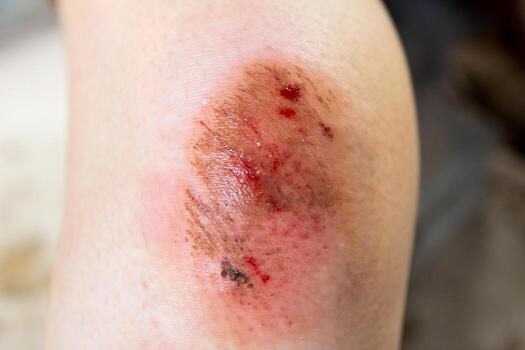

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('bruise.jpg')
cv2_imshow(img)

Saving mxjfiles-bunny-19468.gif to mxjfiles-bunny-19468 (3).gif
Uploaded GIF: mxjfiles-bunny-19468 (3).gif


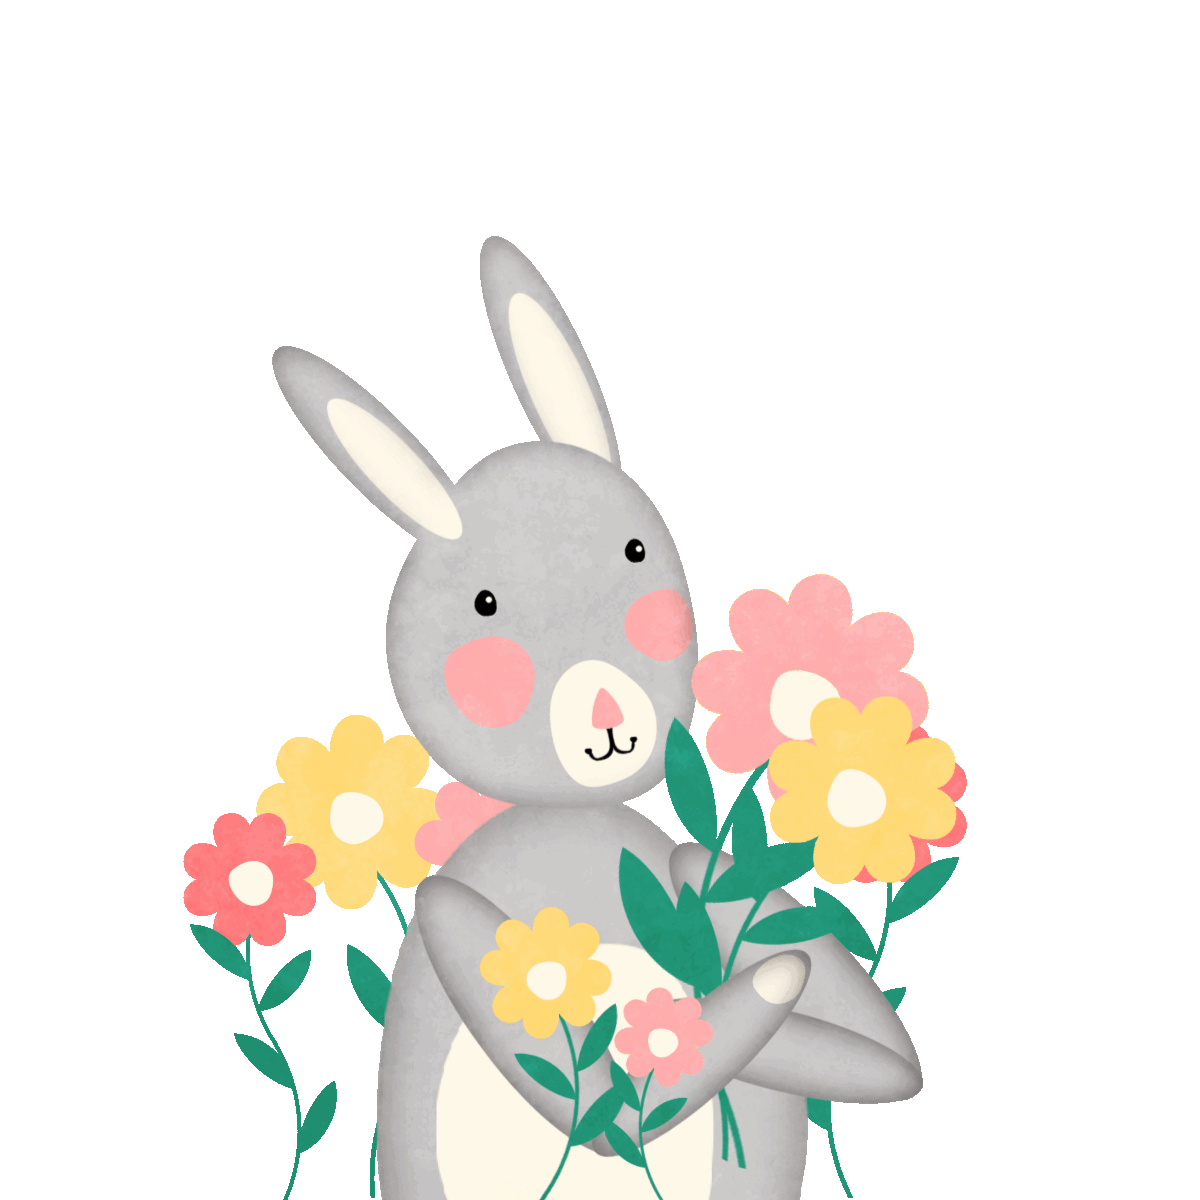

In [ ]:
# Step 1: Upload GIF
from google.colab import files
uploaded = files.upload()  # Upload your .gif file

# Step 2: Get the uploaded file name
gif_filename = list(uploaded.keys())[0]
print("Uploaded GIF:", gif_filename)

# Step 3: Display GIF
from IPython.display import Image, display

display(Image(filename=gif_filename))

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import cv2
import numpy as np

def take_photo(filename='photo.jpg'):
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise(resolve => setTimeout(resolve, 3000));

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg');
        }
    ''')

    display(js)
    data = eval_js('takePhoto()')

    binary = base64.b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# Capture image
file = take_photo()
print("Saved as", file)